# Backpropagation from Scratch,  Building a Scalar Autograd Engine 

**Goal of this notebook.** Build a working autograd engine and a tiny MLP from absolute scratch in pure Python, with no external ML libraries, then train it with gradient descent. Along the way: derive every local derivative rule, implement reverse-mode automatic differentiation via topological sort, and verify numerically that every gradient matches both finite differences and PyTorch.

**What gets built:**

1. A `Value` class that wraps a scalar and remembers how it was computed.
2. Local derivative rules for `+`, `*`, `**`, `exp`, `tanh`, and reflected operators.
3. A reverse-mode `backward()` method that walks the computation graph in reverse topological order.
4. A `Neuron` => `Layer` => `MLP` hierarchy on top of `Value`.
5. A working training loop on a 4-point toy dataset that drives the loss from ~3.7 down to ~0.009 in 50 steps.

---

## Notation

| Symbol | Meaning |
|---|---|
| `x` | a scalar input |
| `w`, `b` | a weight, a bias |
| `n` | the pre-activation `w·x + b` |
| `o` | the post-activation `tanh(n)` |
| `L` | the final scalar (loss) we differentiate w.r.t. |
| `p.data` | the forward value of a `Value` node `p` |
| `p.grad` | ∂L/∂p - the gradient of `L` w.r.t. that node |


## 0. Setup

In [2]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from graphviz import Digraph
%matplotlib inline

---

## 1. Derivatives by definition

Before any autograd machinery, the foundation: a derivative is a slope, defined as a limit. For a function `f(x)`:

```
f'(x) = lim   ( f(x + h) - f(x) ) / h
        h=>0
```

In code we cannot take a true limit; we approximate it with a small finite `h` (this is called the *finite-difference approximation*). The smaller `h`, the closer to the true derivative until floating-point error takes over and ruins the computation.

We will use this numerical derivative as a sanity check throughout the notebook: any analytical gradient we derive must match it.

In [3]:
def f(x):
    return 3*x**2 - 4*x + 5

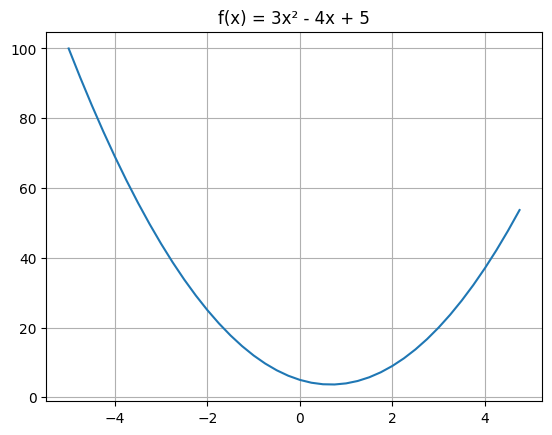

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)

plt.plot(xs, ys)
plt.title('f(x) = 3x² - 4x + 5')
plt.grid()
plt.show()

**Slope at x = 3.** By calculus the derivative is `f'(x) = 6x - 4`, so `f'(3) = 14`. Let's verify numerically.

In [5]:
h = 1e-4
x = 3.0
slope_numerical = (f(x + h) - f(x)) / h
slope_analytical = 6*x - 4
print(f'numerical : {slope_numerical:.2f}')
print(f'analytical: {slope_analytical:.2f}')

numerical : 14.00
analytical: 14.00


**Slope at x = 2/3.** The function has its minimum at `x = 2/3` (set `6x - 4 = 0`), so the slope is exactly 0.

In [6]:
x = 2/3
slope = (f(x + h) - f(x)) / h
print(f'slope at minimum: {slope:.2f}')

slope at minimum: 0.00


---

## 2. Partial derivatives, multi-variable functions

When `f` depends on several inputs, the partial derivative `∂f/∂a` is the slope you get when you nudge **only `a`** while holding everything else fixed. Numerically: bump `a` by `h`, leave `b` and `c` alone, recompute, divide.

Take the function `d = a·b + c` with `a = 2, b = -3, c = 10`. Analytically:

- `∂d/∂a = b = -3`
- `∂d/∂b = a = 2`
- `∂d/∂c = 1`

Verify all three numerically.

In [7]:
def d_of(a, b, c):
    return a*b + c

a, b, c = 2.0, -3.0, 10.0
h = 1e-5

dd_da = (d_of(a + h, b, c) - d_of(a, b, c)) / h
dd_db = (d_of(a, b + h, c) - d_of(a, b, c)) / h
dd_dc = (d_of(a, b, c + h) - d_of(a, b, c)) / h

print(f'∂d/∂a = {dd_da:.4f}   (analytical: {b})')
print(f'∂d/∂b = {dd_db:.4f}   (analytical: {a})')
print(f'∂d/∂c = {dd_dc:.4f}   (analytical: 1)')

∂d/∂a = -3.0000   (analytical: -3.0)
∂d/∂b = 2.0000   (analytical: 2.0)
∂d/∂c = 1.0000   (analytical: 1)


**Key Observation.** This is *exactly* what an autograd engine has to do except instead of nudging each input one by one (which would cost one forward pass *per parameter*), it computes all partial derivatives in a single backward using the chain rule. That cost reduction is the whole reason autograd exists.

Finite differences are O(N) forward passes for N parameters. Reverse-mode autodiff is O(1) backward pass. For a network with millions of parameters, this is the difference between feasible and impossible.

---

## 3. Why plain numbers cannot track gradients

A plain Python float has no memory. The expression

```python
c = a + b
```

stores only the numerical result in `c`. The information *that `c` was made by adding `a` and `b`* is thrown away the moment the line executes. For backprop we need exactly that information without it we cannot walk the chain rule backward from a final loss to the inputs that produced it.

The fix: wrap each scalar in an object that records both its value **and** the operation that built it. That object is the `Value` class.

---

## 4. `Value` v1 tracking the computation graph

Each `Value` carries:

| field | meaning |
|---|---|
| `data` | the scalar value |
| `_prev` | the set of `Value` nodes this one was *computed from* |
| `_op` | a string describing the operation (`'+'`, `'*'`, …), used for visualization |
| `label` | a human-readable name, used for visualization |

The dunder methods `__add__` and `__mul__` are overloaded so that `a + b` and `a * b` produce a new `Value` whose `_prev` and `_op` correctly point back to its parents.

In [8]:
class Value:
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        return Value(self.data + other.data, (self, other), "+")

    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), "*")

Build a small expression and inspect the graph structure that grew implicitly behind it.

In [9]:
a = Value(2.0,  label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b;  e.label = 'e'
d = e + c;  d.label = 'd'
f = Value(-2.0, label='f')
L = d * f;  L.label = 'L'

print(L)
print("L's parents:", L._prev)
print("d's parents:", d._prev)
print("e's parents:", e._prev)

Value(data=-8.0)
L's parents: {Value(data=-2.0), Value(data=4.0)}
d's parents: {Value(data=10.0), Value(data=-6.0)}
e's parents: {Value(data=-3.0), Value(data=2.0)}


---

## 5. Visualizing the graph

A short utility that walks `_prev` pointers and renders the DAG with Graphviz. Used purely for inspection not part of the engine.

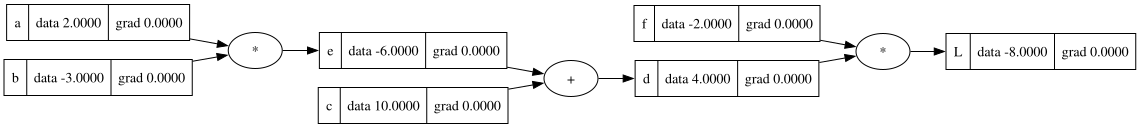

In [10]:
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid,
                 label="{ %s | data %.4f | grad %.4f }" % (
                     n.label, n.data, getattr(n, 'grad', 0.0)),
                 shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

draw_dot(L)

---

## 6. `Value` v2 adding the gradient field

Each node now stores `grad`, initialized to 0.0. After a backward pass, `node.grad` will hold `∂L/∂node` where `L` is whatever scalar we differentiate. We will *manually* set these gradients in the next section to build intuition; automation comes later.

In [11]:
class Value:
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        return Value(self.data + other.data, (self, other), "+")

    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), "*")

---

## 7. Manual backpropagation

We will compute `∂L/∂(every node)` for the expression below by hand, walking backward from `L`. The rule we use at every step is the **chain rule**:

```
∂L/∂x = ∂L/∂(parent of x) · ∂(parent)/∂x
                ^                    ^
         already computed       local derivative
```

So at each node we need only one new fact: **the local derivative of the operation that produced it**.

### 7.1 The expression

In [12]:
a = Value(2.0,  label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b;  e.label = 'e'
d = e + c;  d.label = 'd'
f = Value(-2.0, label='f')
L = d * f;  L.label = 'L'

### 7.2 Base case ∂L/∂L

By definition, the derivative of any quantity with respect to itself is 1.

In [13]:
L.grad = 1.0

### 7.3 Through `L = d * f` local rule for multiplication

For `out = x · y`:

```
∂out/∂x = y
∂out/∂y = x
```

So:

```
∂L/∂d = (∂L/∂L) · (∂L/∂d) = 1 · f = -2
∂L/∂f = (∂L/∂L) · (∂L/∂f) = 1 · d = 4
```

(Here `d.data = a·b + c = -6 + 10 = 4` and `f.data = -2`.)

In [13]:
d.grad = f.data * L.grad   # = -2.0
f.grad = d.data * L.grad   # =  4.0

### 7.4 Through `d = e + c` local rule for addition

For `out = x + y`:

```
∂out/∂x = 1
∂out/∂y = 1
```

So addition is a **gradient distributor**, it passes the gradient from its output down to each parent unchanged.

```
∂L/∂e = ∂L/∂d · 1 = -2
∂L/∂c = ∂L/∂d · 1 = -2
```

In [14]:
e.grad = 1.0 * d.grad
c.grad = 1.0 * d.grad

### 7.5 Through `e = a * b` — multiplication rule again

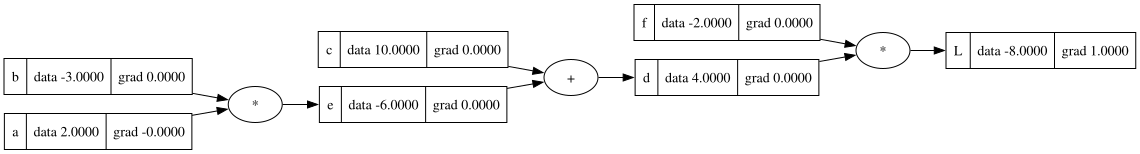

In [15]:
a.grad = b.data * e.grad   # = -3 · -2 = 6
b.grad = a.data * e.grad   # =  2 · -2 = -4

draw_dot(L)

### 7.6 Numerical verification

Compute `∂L/∂a` by finite differences and confirm it equals 6.

In [16]:
def L_of(a_val, b_val, c_val, f_val):
    return (a_val * b_val + c_val) * f_val

base = L_of(2.0, -3.0, 10.0, -2.0)
h = 1e-5
dL_da_numerical = (L_of(2.0 + h, -3.0, 10.0, -2.0) - base) / h
print(f'∂L/∂a numerical: {dL_da_numerical:.2f}   (manual: 6.0)')

∂L/∂a numerical: 6.00   (manual: 6.0)


> **Key Observation, what backprop actually is.**
>
> Every node propagates gradient to its parents using **its own local derivative rule**, multiplied by the gradient already sitting on it (which came from downstream). The chain rule, applied to a graph, is just the recursive application of this single move. That's it. There is nothing else to backpropagation.

### 7.7 The two local rules so far

| operation | output | ∂out/∂(left) | ∂out/∂(right) |
|---|---|---|---|
| `out = x + y` | sum | 1 | 1 |
| `out = x · y` | product | `y` | `x` |

We will add `tanh`, `exp`, `**`, etc. as we need them. Each is one new row in this table.

---

## 8. A single neuron with tanh

A neuron computes:

```
n = w1·x1 + w2·x2 + b
o = tanh(n)
```

This is the smallest non-trivial graph that contains a *nonlinearity*. We will compute the forward pass, then manually backprop through it.

### 8.1 Why we need an activation function

If every layer were just `w·x + b` (linear), then stacking layers would be pointless: a composition of linear functions is itself linear, so a 100-layer "deep" network would compute the *same family of functions* as a 1-layer network. Activation functions inject the curvature that makes deep networks more expressive than shallow ones.

`tanh` is a smooth squashing function bounded in (-1, +1):

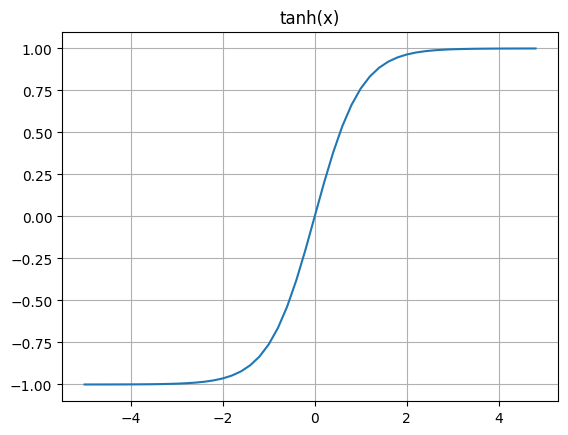

In [17]:
xs = np.arange(-5, 5, 0.2)
plt.plot(xs, np.tanh(xs))
plt.title('tanh(x)')
plt.grid()
plt.show()

### 8.2 `Value` v3, adding `tanh`

Local derivative of tanh:

```
d/dx tanh(x) = 1 - tanh^2(x)
```

We add `tanh` as a new operation on the `Value` class. (Note: this also makes `__add__` / `__mul__` defensive against non-`Value` operands, and adds `__radd__` / `__rmul__` so that expressions like `2 * a` work.)

In [18]:
class Value:
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data + other.data, (self, other), "+")

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data * other.data, (self, other), "*")

    def __radd__(self, other):
        return self + other

    def __rmul__(self, other):
        return self * other

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        return Value(t, (self,), "tanh")

### 8.3 Forward pass

Hand-picked weights so the pre-activation `n` lands at a clean number (`0.8814...`), giving `tanh(n) ≈ 0.7071` convenient for arithmetic checks.

In [19]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0,  label='w2')
b  = Value(6.8813735870195432, label='b')

x1w1 = x1 * w1;            x1w1.label = 'x1*w1'
x2w2 = x2 * w2;            x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2;    x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b;          n.label = 'n'
o = n.tanh();              o.label = 'o'

print(f'n = {n.data:.4f}')
print(f'o = tanh(n) = {o.data:.4f}')

n = 0.8814
o = tanh(n) = 0.7071


### 8.4 Backward pass by hand

Walk the graph backward, applying local rules.

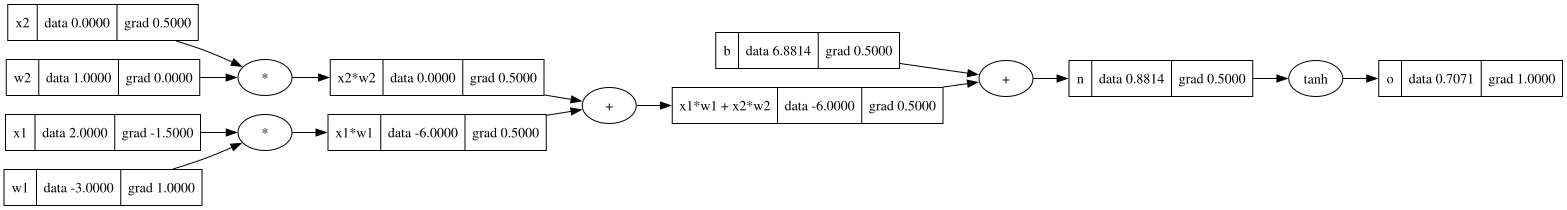

In [20]:
# base case
o.grad = 1.0

# o = tanh(n)  =>  ∂o/∂n = 1 - tanh^2(n) = 1 - o.data^2
n.grad = (1 - o.data**2) * o.grad

# n = (x1*w1 + x2*w2) + b   =>  + distributes gradient
x1w1x2w2.grad = 1.0 * n.grad
b.grad        = 1.0 * n.grad

# x1*w1 + x2*w2 = x1w1 + x2w2  =>  + distributes again
x1w1.grad = 1.0 * x1w1x2w2.grad
x2w2.grad = 1.0 * x1w1x2w2.grad

# x1w1 = x1 * w1  =>  multiplication swaps factors
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

draw_dot(o)

---

## 9. Automating the backward pass

Doing this by hand is fine for a 7-node graph and impossible for a real network. We automate in two steps:

1. **Each operation carries its own `_backward` function** that, given the gradient on the output, knows how to push gradient to its parents. This is a closure created at forward time.
2. **A single `.backward()` method on the root** orchestrates calling every `_backward` in the correct order (reverse topological order).

### 9.1 `Value` v4 per-op `_backward` closures

The closure trick: when an operation runs forward, it creates a `_backward` function that captures the local variables (`self`, `other`, `out`) and stores it on the new node. At backward time, calling `out._backward()` applies that node's local rule.

In [21]:
class Value:
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None    # default no-op (leaves)
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")
        def _backward():
            self.grad  += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")
        def _backward():
            self.grad  += other.data * out.grad
            other.grad += self.data  * out.grad
        out._backward = _backward
        return out

    def __radd__(self, other):
        return self + other

    def __rmul__(self, other):
        return self * other

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), "tanh")
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

> **Note the `+=`.** Gradients are *accumulated*, not assigned. We will explain why in §11. For now: take it on faith that this is the correct chain-rule accumulation.

### 9.2 Topological sort + the `.backward()` method

The local `_backward()` of a node uses `out.grad` on the right-hand side. So before we call it, `out.grad` must already be *fully computed*. This means we have to visit nodes in an order where every node is processed only **after** every node that depends on it.

That order is **reverse topological order**.

A topological order of a DAG is any linear ordering where every node comes after all its parents. Post-order DFS produces one. Reversing it gives us "from output to inputs" exactly what backprop needs.

In [22]:
class Value:
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")
        def _backward():
            self.grad  += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")
        def _backward():
            self.grad  += other.data * out.grad
            other.grad += self.data  * out.grad
        out._backward = _backward
        return out

    def __radd__(self, other):
        return self + other

    def __rmul__(self, other):
        return self * other

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), "tanh")
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

### 9.3 End-to-end check same neuron, automatic backward

Rebuild the neuron from §8.3 and compare the gradients produced by `o.backward()` against the manual ones we computed earlier. They should be identical.

In [24]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0,  label='w2')
b  = Value(6.8813735870195432, label='b')

n = x1*w1 + x2*w2 + b
o = n.tanh()

o.backward()

print(f'∂o/∂x1 = {x1.grad:.4f}')
print(f'∂o/∂w1 = {w1.grad:.4f}')
print(f'∂o/∂x2 = {x2.grad:.4f}')
print(f'∂o/∂w2 = {w2.grad:.4f}')
print(f'∂o/∂b  = {b.grad:.4f}')

∂o/∂x1 = -1.5000
∂o/∂w1 = 1.0000
∂o/∂x2 = 0.5000
∂o/∂w2 = 0.0000
∂o/∂b  = 0.5000


---

## 10. Why gradients are *accumulated* (the `+=`)

Consider `b = a + a`. Analytically `db/da = 2`, because `a` enters the expression twice and the chain rule sums the contributions from each path.

If `_backward` *assigned* gradient (`self.grad = 1.0 * out.grad`) instead of *accumulating* it (`self.grad += 1.0 * out.grad`), the second write would overwrite the first and we'd get `db/da = 1`. Wrong.

This is the **multivariate chain rule**: when a node `a` affects the output through multiple paths, the total gradient is the sum over all paths. `+=` implements that summation naturally.

In [26]:
a = Value(3.0, label='a')
b = a + a
b.label = 'b'
b.backward()
print(f'db/da = {a.grad}   (expected: 2.0)')

db/da = 2.0   (expected: 2.0)


A more subtle "diamond" shape `a` flows into `f` through both `d` and `e`:

In [27]:
a = Value(-2.0, label='a')
b = Value(3.0,  label='b')
d = a * b;  d.label = 'd'
e = a + b;  e.label = 'e'
f = d * e;  f.label = 'f'

f.backward()
print(f'∂f/∂a = {a.grad}')
print(f'∂f/∂b = {b.grad}')

∂f/∂a = -3.0
∂f/∂b = -8.0


> **Trap.** This is exactly why we must zero gradients before each training iteration. The `+=` is correct *within* a single backward pass (it implements the multivariate chain rule), but it would also accumulate **across** passes if we didn't reset. Every modern framework has the same property that's what `optimizer.zero_grad()` does in PyTorch.

---

## 11. `tanh` is not special decomposing it into primitives

So far `tanh` is an atomic operation with its own `_backward`. We will now show that we can rebuild it from `exp`, `+`, `-`, `/` and constants provided each of those has its own `_backward` and the gradient through this composition will match the atomic version exactly.

This proves that the engine has no privileged set of "supported" functions. Any function expressible from primitive operations is automatically differentiable for free.

### 11.1 The full `Value` class

We add:

- `exp` needed because `tanh(x) = (e^(2x) - 1) / (e^(2x) + 1)`.
- `__pow__(self, k)`  - for `k ∈ {int, float}`. Used to express division: `a / b = a · b^(-1)`.
- `__neg__`, `__sub__`, `__truediv__` — composed from existing ops, so they need no new `_backward`.
- Reflected operators `__radd__`, `__rmul__`, `__rsub__`, `__rtruediv__` — make `2 * a`, `1 - a`, `1 / a` etc. work when `Value` is on the right.

Local derivative rules added:

| operation | local derivative |
|---|---|
| `out = exp(x)` | `∂out/∂x = exp(x) = out.data` |
| `out = x ** k` (k constant) | `∂out/∂x = k · x^(k-1)` |

In [33]:
class Value:
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    # ------------- core ops with local backward rules -------------

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")
        def _backward():
            self.grad  += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")
        def _backward():
            self.grad  += other.data * out.grad
            other.grad += self.data  * out.grad
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only int/float powers supported"
        out = Value(self.data ** other, (self,), f"**{other}")
        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), "exp")
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), "tanh")
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def sigmoid(self):
        out_data = 1 / (1 + math.exp(-self.data))
        out = Value(out_data, (self,), "sigmoid")
    
        def _backward():
            self.grad += out_data * (1 - out_data) * out.grad
        out._backward = _backward
        return out

    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')

        def _backward():
            # The gradient is 1.0 if the input was positive, otherwise 0.0
            self.grad += (1.0 if out.data > 0 else 0.0) * out.grad
        
        out._backward = _backward
        return out 
            

    # ----- composed ops (no new backward needed) ----

    def __neg__(self):       return self * -1
    def __sub__(self, other): return self + (-other)
    def __truediv__(self, other): return self * other**-1

    # ---- reflected (right-hand-side) operators ----

    def __radd__(self, other): return self + other
    def __rmul__(self, other): return self * other
    def __rsub__(self, other): return other + (-self)
    def __rtruediv__(self, other): return other * self**-1

    # ------ backward orchestrator ----

    def backward(self):
        topo, visited = [], set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

### 11.2 Rebuilding `tanh` from primitives

Use the closed form `tanh(x) = (e^(2x) - 1) / (e^(2x) + 1)` directly, with no call to `.tanh()`. The engine should still produce identical gradients to the atomic version.

In [34]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0,  label='w2')
b  = Value(6.8813735870195432, label='b')

n = x1*w1 + x2*w2 + b

# tanh, decomposed:
e = (2*n).exp()
o = (e - 1) / (e + 1)
o.label = 'o'

o.backward()

print(f'forward o = {o.data:.6f}   (atomic tanh would give same value)')
print()
print(f'∂o/∂x1 = {x1.grad:.4f}')
print(f'∂o/∂w1 = {w1.grad:.4f}')
print(f'∂o/∂x2 = {x2.grad:.4f}')
print(f'∂o/∂w2 = {w2.grad:.4f}')
print(f'∂o/∂b  = {b.grad:.4f}')

forward o = 0.707107   (atomic tanh would give same value)

∂o/∂x1 = -1.5000
∂o/∂w1 = 1.0000
∂o/∂x2 = 0.5000
∂o/∂w2 = 0.0000
∂o/∂b  = 0.5000


These match the gradients from §9.3 exactly the engine produced the same numbers via four primitive ops (`*`, `exp`, `-`, `/`) instead of one atomic `tanh`. **`tanh` was never special. It was just a convenience.**

---

## 12. Cross-checking against PyTorch

The ultimate test: build the same neuron in PyTorch and compare. If our gradients match PyTorch's to many decimal places, the engine is architecturally correct.

In [35]:
import torch

x1 = torch.tensor([2.0], dtype=torch.float64, requires_grad=True)
x2 = torch.tensor([0.0], dtype=torch.float64, requires_grad=True)
w1 = torch.tensor([-3.0], dtype=torch.float64, requires_grad=True)
w2 = torch.tensor([1.0],  dtype=torch.float64, requires_grad=True)
b  = torch.tensor([6.8813735870195432], dtype=torch.float64, requires_grad=True)

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(f'forward o = {o.item():.6f}')
o.backward()

print()
print(f'∂o/∂x1 = {x1.grad.item():.4f}')
print(f'∂o/∂w1 = {w1.grad.item():.4f}')
print(f'∂o/∂x2 = {x2.grad.item():.4f}')
print(f'∂o/∂w2 = {w2.grad.item():.4f}')
print(f'∂o/∂b  = {b.grad.item():.4f}')

forward o = 0.707107

∂o/∂x1 = -1.5000
∂o/∂w1 = 1.0000
∂o/∂x2 = 0.5000
∂o/∂w2 = 0.0000
∂o/∂b  = 0.5000


The engine is a faithful, if minimal, scalar version of PyTorch's autograd.

> **What PyTorch does differently:** it operates on *tensors* (vectorized, GPU-friendly), only stores `.grad` on leaf tensors by default, and uses an iterative topological sort to handle deeper graphs. The mathematical content is the same.

---

## 13. From scalars to a neural network

With autograd in place, an MLP is a thin wrapper over `Value`. Three classes:

- **`Neuron`** — owns its own weights and bias (`Value` objects), computes `tanh(Σwixi + b)`.
- **`Layer`** — a list of independent neurons that share the same input.
- **`MLP`** — a list of layers, applied in sequence.

Each class also exposes a `parameters()` method that returns every trainable `Value` it contains. This is what the training loop iterates over to zero gradients and apply updates.

In [36]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # Σ wi·xi + b
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        return act.tanh()

    def parameters(self):
        return self.w + [self.b]


class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]


class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

### 13.1 Inspect the architecture

A 3 => 4 => 4 => 1 network has 41 trainable parameters: (3·4 + 4) + (4·4 + 4) + (4·1 + 1) = 16 + 20 + 5

In [37]:
random.seed(42)
n = MLP(3, [4, 4, 1])
print(f'parameter count: {len(n.parameters())}')
print(f'sample forward pass on [2.0, 3.0, -1.0]: {n([2.0, 3.0, -1.0])}')

parameter count: 41
sample forward pass on [2.0, 3.0, -1.0]: Value(data=0.6994093620224068)


---

## 14. Training the MLP

A 4-point binary-style toy dataset, full-batch sum-of-squared-errors loss, vanilla gradient descent.

### 14.1 Dataset

In [38]:
xs = [
    [2.0,  3.0, -1.0],
    [3.0, -1.0,  0.5],
    [0.5,  1.0,  1.0],
    [1.0,  1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]   # targets

### 14.2 Loss

Sum of squared errors:

```
L = Σᵢ (ŷᵢ - yᵢ)²
```

(The mean would just rescale the gradient by 1/N — equivalent up to a learning-rate constant.)

### 14.3 The training loop

Each iteration has four phases:

1. **Forward pass.** Compute predictions and the loss. As a side effect, the full computation graph is built.
2. **Zero gradients.** Clear `p.grad` for every parameter otherwise we'd accumulate this iteration's gradients on top of the previous one's.
3. **Backward pass.** `loss.backward()` walks the graph in reverse topological order; afterwards every `p.grad = ∂L/∂p`.
4. **Update.** Vanilla gradient descent: `p <= p - γ · p.grad`. Here `γ = 0.05`.

In [39]:
random.seed(42)
n = MLP(3, [4, 4, 1])

losses = []
for k in range(50):
    # 1. forward
    ypred = [n(x) for x in xs]
    loss = sum((yhat - y)**2 for y, yhat in zip(ys, ypred))

    # 2. zero gradients
    for p in n.parameters():
        p.grad = 0.0

    # 3. backward
    loss.backward()

    # 4. update
    for p in n.parameters():
        p.data += -0.05 * p.grad

    losses.append(loss.data)
    if k % 5 == 0 or k == 49:
        print(f'step {k:>2} | loss = {loss.data:.6f}')

step  0 | loss = 5.230518
step  5 | loss = 0.595722
step 10 | loss = 0.213094
step 15 | loss = 0.123364
step 20 | loss = 0.084463
step 25 | loss = 0.063295
step 30 | loss = 0.050164
step 35 | loss = 0.041297
step 40 | loss = 0.034942
step 45 | loss = 0.030184
step 49 | loss = 0.027169


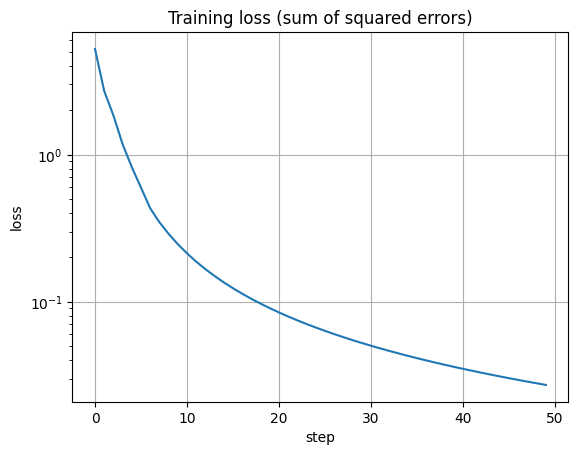

In [40]:
plt.plot(losses)
plt.xlabel('step')
plt.ylabel('loss')
plt.title('Training loss (sum of squared errors)')
plt.yscale('log')
plt.grid()
plt.show()

### 14.4 Final predictions vs targets

In [41]:
ypred = [n(x) for x in xs]
for x, y, yhat in zip(xs, ys, ypred):
    print(f'x = {x}   target = {y:+.1f}   prediction = {yhat.data:+.4f}')

x = [2.0, 3.0, -1.0]   target = +1.0   prediction = +0.9144
x = [3.0, -1.0, 0.5]   target = -1.0   prediction = -0.9479
x = [0.5, 1.0, 1.0]   target = -1.0   prediction = -0.8949
x = [1.0, 1.0, -1.0]   target = +1.0   prediction = +0.9265


The network has driven all four predictions within ~0.05 of their targets. With only 4 training points and 41 parameters this is heavy overfitting  but that is exactly the goal here: demonstrate that the autograd engine is correct end-to-end.

> **What we did *not* use:** momentum, weight decay, mini-batching, learning-rate schedules, adaptive optimizers, batch/layer norm, dropout, or any initialization scheme more sophisticated than `uniform(-1, 1)`. A research-grade training loop is built from the same four phases only the optimizer, loss, regularization, and data pipeline are different.

---

## 15. Concept checklist what this notebook demonstrates

-  **The derivative as a numerical limit** and as an analytical local rule.
-  **Partial derivatives** via finite differences, and why the O(N) cost motivates autograd.
-  **A computation graph** built implicitly by overloading Python operators on a `Value` class.
-  **The chain rule applied recursively over a DAG** i.e. backpropagation, derived from scratch.
-  **Local derivative rules** for `+`, `*`, `**`, `exp`, `tanh`, plus reflected operators.
-  **Closures as carriers of local backward rules** each operation attaches a `_backward` to its output node.
-  **Reverse topological order** as the unique correct traversal for backprop (each node's gradient must be fully accumulated before propagating onward).
-  **Gradient accumulation (`+=`)** as the implementation of the multivariate chain rule across multiple paths and the same accumulation property as the reason `optimizer.zero_grad()` exists.
-  **Decomposability** `tanh` rebuilt from `exp`, `+`, `-`, `/` produces identical gradients, proving no operation is privileged.
-  **Numerical agreement with PyTorch** to many decimal places.
-  **The full training pipeline**: forward => zero grads => backward => update.

---

## What this maps to in real frameworks

| micrograd concept | PyTorch equivalent |
|---|---|
| `Value` | `torch.Tensor` with `requires_grad=True` |
| `_prev`, `_op` | the autograd graph (internal `grad_fn` chain) |
| `_backward` closure | autograd `Function.backward` |
| `Value.backward()` | `Tensor.backward()` |
| `for p in n.parameters(): p.grad = 0.0` | `optimizer.zero_grad()` |
| `for p in n.parameters(): p.data += -lr * p.grad` | `optimizer.step()` (for plain SGD) |
| `Neuron`, `Layer`, `MLP` | `nn.Linear`, `nn.Sequential`, `nn.Module` |

The engineering is much heavier in PyTorch vectorized tensors, GPU kernels, fused ops, an iterative topological sort, gradient checkpointing but the **mathematical content is the same**. After this notebook, nothing inside `loss.backward()` is mysterious anymore.